<a href="https://colab.research.google.com/github/monishms2128/PALSHACKATHONCHALLENGES/blob/main/HACKATHONTASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
datasets = pd.read_excel('/content/Company_x.xlsx')

In [ ]:
datasets.head()

,EntityID,OriginalCreditor[Redacted],AccountID,CurrentBalance,DebtLoadPrincipal,Balanaceatdebt_load,PurchasePrice,ProductOrDebtType,CollectionStatus,ClosureReason,...,LastPaymentMethod,NumLiableParties,CustomerAge,NumPhones,NumEmails,NumAddresses,IsStatBarred,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,932,Creditor 1,3677,0.0,1160.20,1160.20,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,53.0,0,0,1,N,NaN,NaN,NaN
1,160,Creditor 2,4276,182.9,182.90,182.90,4.22,Other,CANCELLED_WITHDRAWN,NaN,...,NaN,1.0,NaN,0,0,1,Y,NaN,NaN,NaN
2,932,Creditor 1,8525,0.0,538.57,538.57,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,NaN,1,0,1,N,NaN,NaN,NaN
3,160,Creditor 2,9859,8279.5,8279.50,8279.50,4.22,Other,PASSIVE,NaN,...,NaN,1.0,NaN,1,0,1,Y,NaN,NaN,NaN
4,932,Creditor 1,12807,0.0,523.00,523.00,4.22,Other,PAID_IN_FULL,NaN,...,Cheque,1.0,46.0,2,0,1,Y,NaN,NaN,NaN


In [ ]:
datasets.shape

(406423, 25)

In [ ]:
datasets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406423 entries, 0 to 406422
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   EntityID                    406423 non-null  int64  
 1   OriginalCreditor[Redacted]  406423 non-null  object 
 2   AccountID                   406423 non-null  int64  
 3   CurrentBalance              406423 non-null  float64
 4   DebtLoadPrincipal           406423 non-null  float64
 5   Balanaceatdebt_load         406423 non-null  float64
 6   PurchasePrice               403731 non-null  float64
 7   ProductOrDebtType           406423 non-null  object 
 8   CollectionStatus            406423 non-null  object 
 9   ClosureReason               9030 non-null    object 
 10  InBankruptcy                406423 non-null  object 
 11  AccountInsolvencyType       285 non-null     object 
 12  CustomerInsolvencyType      8531 non-null    object 
 13  IsLegal       

In [ ]:
datasets.isnull().sum()

,0
EntityID,0
OriginalCreditor[Redacted],0
AccountID,0
CurrentBalance,0
DebtLoadPrincipal,0
Balanaceatdebt_load,0
PurchasePrice,2692
ProductOrDebtType,0
CollectionStatus,0
ClosureReason,397393


In [ ]:
datasets.isnull().sum() / len(datasets) * 100

,0
EntityID,0.000000
OriginalCreditor[Redacted],0.000000
AccountID,0.000000
CurrentBalance,0.000000
DebtLoadPrincipal,0.000000
Balanaceatdebt_load,0.000000
PurchasePrice,0.662364
ProductOrDebtType,0.000000
CollectionStatus,0.000000
ClosureReason,97.778177


In [ ]:
datasets = datasets.drop(
    columns=['Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
)

In [ ]:
datasets.shape

(406423, 22)

In [ ]:
datasets['IsStatBarred'].value_counts()

,count
IsStatBarred,
Y,284548
N,121875


In [ ]:
datasets['IsStatBarred'].value_counts(normalize=True) * 100

,proportion
IsStatBarred,
Y,70.01277
N,29.98723


In [ ]:
datasets.dtypes

,0
EntityID,int64
OriginalCreditor[Redacted],object
AccountID,int64
CurrentBalance,float64
DebtLoadPrincipal,float64
Balanaceatdebt_load,float64
PurchasePrice,float64
ProductOrDebtType,object
CollectionStatus,object
ClosureReason,object


In [ ]:
datasets.isnull().sum()

,0
EntityID,0
OriginalCreditor[Redacted],0
AccountID,0
CurrentBalance,0
DebtLoadPrincipal,0
Balanaceatdebt_load,0
PurchasePrice,2692
ProductOrDebtType,0
CollectionStatus,0
ClosureReason,397393


In [ ]:
categorical_cols = [
    'ClosureReason',
    'AccountInsolvencyType',
    'CustomerInsolvencyType',
    'LastPaymentMethod'
]

for col in categorical_cols:
    datasets[col] = datasets[col].fillna(datasets[col].mode()[0])

datasets[categorical_cols].isnull().sum()

,0
ClosureReason,0
AccountInsolvencyType,0
CustomerInsolvencyType,0
LastPaymentMethod,0


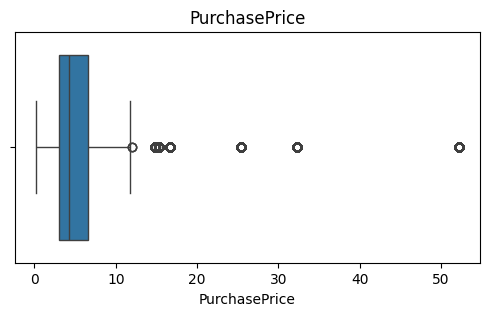

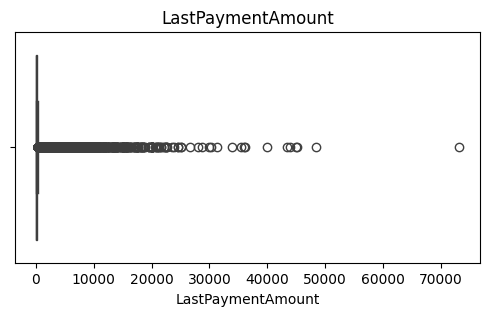

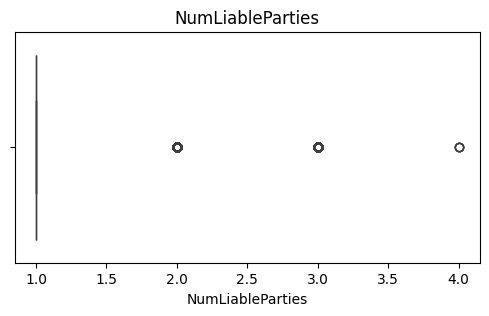

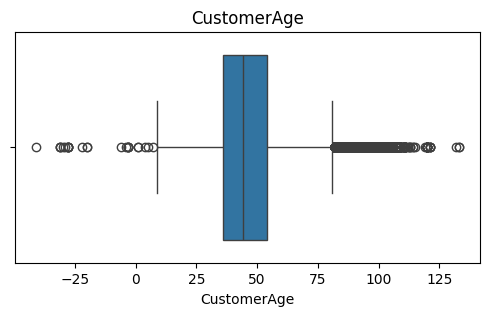

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = [
    'PurchasePrice',
    'LastPaymentAmount',
    'NumLiableParties',
    'CustomerAge'
]

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=datasets[col])
    plt.title(col)
    plt.show()

In [ ]:
for col in numerical_cols:
    Q1 = datasets[col].quantile(0.25)
    Q3 = datasets[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((datasets[col] < lower) | (datasets[col] > upper)).sum()

    print(col, "→ Outliers:", outliers)

PurchasePrice → Outliers: 10688
LastPaymentAmount → Outliers: 15450
NumLiableParties → Outliers: 6807
CustomerAge → Outliers: 4094


In [ ]:
for col in numerical_cols:
    datasets[col] = datasets[col].fillna(datasets[col].median())

datasets[numerical_cols].isnull().sum()

,0
PurchasePrice,0
LastPaymentAmount,0
NumLiableParties,0
CustomerAge,0


In [ ]:
y = datasets['IsStatBarred'].map({'N': 0, 'Y': 1})

x = datasets.drop('IsStatBarred', axis=1)

y.value_counts()

,count
IsStatBarred,
1,284548
0,121875


In [ ]:
categorical_cols = x.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, "→", x[col].nunique(), "unique values")

OriginalCreditor[Redacted] → 52 unique values
ProductOrDebtType → 10 unique values
CollectionStatus → 12 unique values
ClosureReason → 14 unique values
InBankruptcy → 2 unique values
AccountInsolvencyType → 5 unique values
CustomerInsolvencyType → 13 unique values
IsLegal → 2 unique values
LastPaymentMethod → 9 unique values


In [ ]:
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True, dtype=int)

x.shape

(406423, 122)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled.shape

(406423, 122)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train:", x_train.shape)
print("X Test:", x_test.shape)
print("Y Train:", y_train.shape)
print("Y Test:", y_test.shape)

X Train: (325138, 122)
X Test: (81285, 122)
Y Train: (325138,)
Y Test: (81285,)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential()

model.add(layers.Input(shape=(122,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,497 (41.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9741 - loss: 0.0747 - val_accuracy: 0.9776 - val_loss: 0.0626
Epoch 2/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9783 - loss: 0.0594 - val_accuracy: 0.9779 - val_loss: 0.0602
Epoch 3/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9788 - loss: 0.0559 - val_accuracy: 0.9775 - val_loss: 0.0571
Epoch 4/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9792 - loss: 0.0534 - val_accuracy: 0.9787 - val_loss: 0.0546
Epoch 5/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9794 - loss: 0.0521 - val_accuracy: 0.9787 - val_loss: 0.0541
Epoch 6/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9797 - loss: 0.0513 - val_accuracy: 0.9791 - val_loss: 0.0547
Epoch 7/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9801 - loss: 0.0506 - val_accuracy: 0.9785 - val_loss: 0.0544
Epoch 8/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9801 - loss: 0

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy %:", accuracy * 100)

2541/2541 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9790 - loss: 0.0539
Test Loss: 0.05391916632652283
Test Accuracy: 0.979049026966095
Test Accuracy %: 97.9049026966095


In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(y_pred[:10])

2541/2541 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
[0 0 0 1 1 1 1 1 1 1]


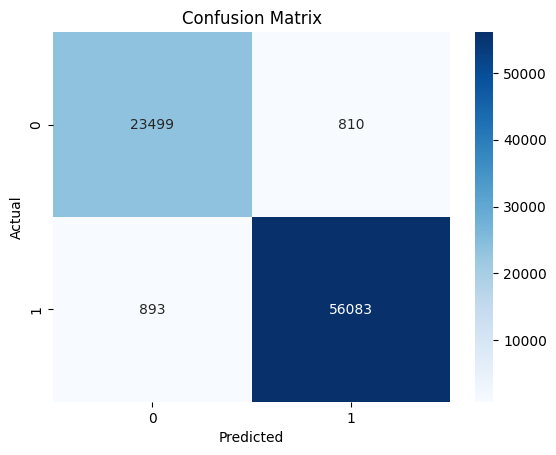

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     24309
           1       0.99      0.98      0.99     56976

    accuracy                           0.98     81285
   macro avg       0.97      0.98      0.98     81285
weighted avg       0.98      0.98      0.98     81285



In [ ]:
model2 = keras.Sequential()

model2.add(layers.Input(shape=(122,)))

model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

model2.add(layers.Dense(32, activation='relu'))
model2.add(layers.Dropout(0.2))

model2.add(layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,881 (105.00 KB)

 Trainable params: 26,497 (103.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
for col in ['CollectionStatus', 'ClosureReason', 'InBankruptcy',
            'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal']:
    print("\n", col)
    print(pd.crosstab(datasets[col], datasets['IsStatBarred'], normalize='index').round(3))


 CollectionStatus
IsStatBarred             N      Y
CollectionStatus                 
ACTIVE               0.179  0.821
CANCELLED_WITHDRAWN  0.983  0.017
CLOSED               0.536  0.464
HOLDING              0.881  0.119
LEGAL                0.516  0.484
LEGAL_ARRANGEMENT    1.000  0.000
NON_COLLECTION       0.143  0.857
PAID_IN_FULL         0.988  0.012
PASSIVE              0.007  0.993
PENDING              0.963  0.037
SETTLED FOR LESS     0.962  0.038
UNDER_ARRANGEMENT    0.985  0.015

 ClosureReason
IsStatBarred                         N      Y
ClosureReason                                
Client Instructions              0.781  0.219
Company Struck Off               0.811  0.189
Deceased                         0.644  0.356
Disputes/Legal Case Lost         1.000  0.000
Duplicate Debt                   1.000  0.000
Fraud                            0.760  0.240
Incarcerated                     1.000  0.000
Insolvent                        0.299  0.701
Other Reason - Please see not

In [ ]:
x_safe = datasets.drop(
    ['IsStatBarred', 'CollectionStatus', 'ClosureReason'],
    axis=1
)

categorical_safe = x_safe.select_dtypes(include='object').columns

x_safe = pd.get_dummies(
    x_safe,
    columns=categorical_safe,
    drop_first=True,
    dtype=int
)

print("Features after removing CollectionStatus and ClosureReason:", x_safe.shape)

Features after removing CollectionStatus and ClosureReason: (406423, 98)


In [ ]:
x_safe.shape

(406423, 98)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_safe_train, x_safe_test, y_safe_train, y_safe_test = train_test_split(
    x_safe,
    y,
    test_size=0.2,
    random_state=42
)

scaler_safe = StandardScaler()

x_safe_train = scaler_safe.fit_transform(x_safe_train)
x_safe_test = scaler_safe.transform(x_safe_test)

print("X Train:", x_safe_train.shape)
print("X Test:", x_safe_test.shape)

X Train: (325138, 98)
X Test: (81285, 98)


In [ ]:
model2 = keras.Sequential()

model2.add(layers.Input(shape=(98,)))
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.BatchNormalization())
model2.add(layers.Dropout(0.3))

model2.add(layers.Dense(32, activation='relu'))
model2.add(layers.Dropout(0.2))

model2.add(layers.Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        12,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history2 = model2.fit(
    x_safe_train,
    y_safe_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_safe_test, y_safe_test)
)

Epoch 1/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.8985 - loss: 0.2595 - val_accuracy: 0.9101 - val_loss: 0.2308
Epoch 2/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9225 - loss: 0.2032 - val_accuracy: 0.9134 - val_loss: 0.2387
Epoch 3/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9254 - loss: 0.1954 - val_accuracy: 0.9139 - val_loss: 0.2275
Epoch 4/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9276 - loss: 0.1898 - val_accuracy: 0.9125 - val_loss: 0.2395
Epoch 5/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9301 - loss: 0.1845 - val_accuracy: 0.9139 - val_loss: 0.2443
Epoch 6/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9297 - loss: 0.1846 - val_accuracy: 0.9214 - val_loss: 0.2430
Epoch 7/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9315 - loss: 0.1820 - val_accuracy: 0.9270 - val_loss: 0.2578
Epoch 8/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9344 - loss: 0

In [ ]:
loss2, accuracy2 = model2.evaluate(
    x_safe_test,
    y_safe_test
)

print("Model 2 Test Loss:", loss2)
print("Model 2 Test Accuracy:", accuracy2)
print("Model 2 Test Accuracy %:", accuracy2 * 100)

2541/2541 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9172 - loss: 0.2296
Model 2 Test Loss: 0.22962982952594757
Model 2 Test Accuracy: 0.9171802997589111
Model 2 Test Accuracy %: 91.71802997589111


In [ ]:
datasets3 = pd.read_excel('/content/Company_x.xlsx')

datasets3 = datasets3.drop(
    columns=['Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
)

print(datasets3.shape)

(406423, 22)


In [ ]:
high_missing_cols = [
    'ClosureReason',
    'AccountInsolvencyType',
    'CustomerInsolvencyType'
]

for col in high_missing_cols:
    datasets3[col] = datasets3[col].fillna('Missing')

print(datasets3[high_missing_cols].isnull().sum())

ClosureReason             0
AccountInsolvencyType     0
CustomerInsolvencyType    0
dtype: int64


In [ ]:
datasets3['LastPaymentMethod'] = datasets3['LastPaymentMethod'].fillna('Missing')

print(datasets3['LastPaymentMethod'].isnull().sum())


0


In [ ]:
numerical_cols3 = [
    'PurchasePrice',
    'LastPaymentAmount',
    'NumLiableParties',
    'CustomerAge'
]

for col in numerical_cols3:
    datasets3[col] = datasets3[col].fillna(datasets3[col].median())

print(datasets3[numerical_cols3].isnull().sum())

PurchasePrice        0
LastPaymentAmount    0
NumLiableParties     0
CustomerAge          0
dtype: int64


In [ ]:
y3 = datasets3['IsStatBarred'].map({'N': 0, 'Y': 1})

x3 = datasets3.drop('IsStatBarred', axis=1)

print("X shape:", x3.shape)
print("Y shape:", y3.shape)

X shape: (406423, 21)
Y shape: (406423,)


In [ ]:
categorical_cols3 = x3.select_dtypes(include='object').columns

print("Categorical columns:", list(categorical_cols3))

x3 = pd.get_dummies(
    x3,
    columns=categorical_cols3,
    drop_first=True,
    dtype=int
)

print("New X shape:", x3.shape)

Categorical columns: ['OriginalCreditor[Redacted]', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentMethod']
New X shape: (406423, 126)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x3_train, x3_test, y3_train, y3_test = train_test_split(
    x3,
    y3,
    test_size=0.2,
    random_state=42
)

scaler3 = StandardScaler()

x3_train = scaler3.fit_transform(x3_train)
x3_test = scaler3.transform(x3_test)

print("X Train:", x3_train.shape)
print("X Test:", x3_test.shape)

X Train: (325138, 126)
X Test: (81285, 126)


In [ ]:
model3 = keras.Sequential()

model3.add(layers.Input(shape=(126,)))
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dense(32, activation='relu'))
model3.add(layers.Dense(16, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history3 = model3.fit(
    x3_train,
    y3_train,
    epochs=10,
    batch_size=64,
    validation_data=(x3_test, y3_test)
)

Epoch 1/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9759 - loss: 0.0713 - val_accuracy: 0.9783 - val_loss: 0.0618
Epoch 2/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9796 - loss: 0.0572 - val_accuracy: 0.9793 - val_loss: 0.0577
Epoch 3/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9801 - loss: 0.0538 - val_accuracy: 0.9795 - val_loss: 0.0543
Epoch 4/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9807 - loss: 0.0509 - val_accuracy: 0.9797 - val_loss: 0.0551
Epoch 5/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9808 - loss: 0.0495 - val_accuracy: 0.9797 - val_loss: 0.0526
Epoch 6/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9810 - loss: 0.0487 - val_accuracy: 0.9798 - val_loss: 0.0535
Epoch 7/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9812 - loss: 0.0481 - val_accuracy: 0.9803 - val_loss: 0.0529
Epoch 8/10
5081/5081 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9813 - loss: 0

In [ ]:
loss3, accuracy3 = model3.evaluate(x3_test, y3_test)

print("Model 3 Test Loss:", loss3)
print("Model 3 Test Accuracy:", accuracy3)
print("Model 3 Test Accuracy %:", accuracy3 * 100)

2541/2541 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9798 - loss: 0.0529
Model 3 Test Loss: 0.052914250642061234
Model 3 Test Accuracy: 0.9797502756118774
Model 3 Test Accuracy %: 97.97502756118774


2541/2541 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


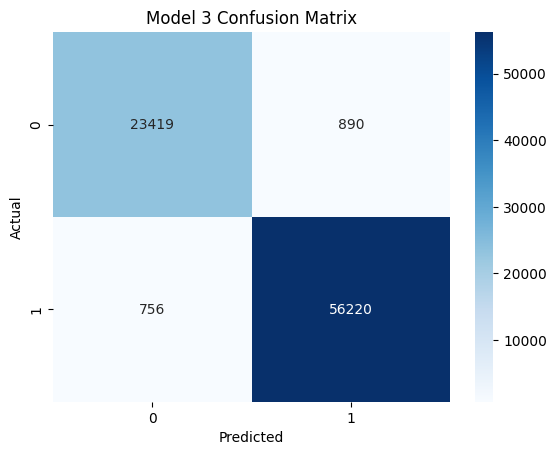

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y3_pred_prob = model3.predict(x3_test)
y3_pred = (y3_pred_prob > 0.5).astype(int).flatten()

cm3 = confusion_matrix(y3_test, y3_pred)

sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model 3 Confusion Matrix')
plt.show()


In [ ]:
id="cr3"
from sklearn.metrics import classification_report

print(classification_report(y3_test, y3_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     24309
           1       0.98      0.99      0.99     56976

    accuracy                           0.98     81285
   macro avg       0.98      0.98      0.98     81285
weighted avg       0.98      0.98      0.98     81285



In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# ============================================================
# LOAD ORIGINAL DATA
# ============================================================

raw_df = pd.read_excel(
    "/content/Company_x.xlsx",
    sheet_name="Debtbook"
)

raw_df = raw_df.drop(
    columns=["Unnamed: 22", "Unnamed: 23", "Unnamed: 24"],
    errors="ignore"
)

# ============================================================
# COLUMNS
# ============================================================

categorical_cols = [
    "OriginalCreditor[Redacted]",
    "ProductOrDebtType",
    "CollectionStatus",
    "ClosureReason",
    "InBankruptcy",
    "AccountInsolvencyType",
    "CustomerInsolvencyType",
    "IsLegal",
    "LastPaymentMethod"
]

# ============================================================
# CREATE CATEGORY LISTS
# ============================================================

def get_values(col):
    return sorted(
        raw_df[col].dropna().astype(str).unique().tolist()
    )

creditors = get_values("OriginalCreditor[Redacted]")
products = get_values("ProductOrDebtType")
collection = get_values("CollectionStatus")
closure = get_values("ClosureReason")
bankruptcy = get_values("InBankruptcy")
account_insolvency = get_values("AccountInsolvencyType")
customer_insolvency = get_values("CustomerInsolvencyType")
legal = get_values("IsLegal")
payment_method = get_values("LastPaymentMethod")

# ============================================================
# FIND REAL EXAMPLES FROM DATASET
# ============================================================

# Real NOT STATUTE BARRED example
not_barred_rows = raw_df[
    raw_df["IsStatBarred"].astype(str) == "N"
]

# Real STATUTE BARRED example
barred_rows = raw_df[
    raw_df["IsStatBarred"].astype(str) == "Y"
]

not_barred_base = (
    not_barred_rows.iloc[0]
    if len(not_barred_rows) > 0
    else raw_df.iloc[0]
)

barred_base = (
    barred_rows.iloc[0]
    if len(barred_rows) > 0
    else raw_df.iloc[0]
)

# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_debt(
    scenario,
    current_balance,
    debt_load_principal,
    balance_at_debt_load,
    purchase_price,
    last_payment_amount,
    num_liable_parties,
    customer_age,
    num_phones,
    num_emails,
    num_addresses,
    original_creditor,
    product_type,
    collection_status,
    closure_reason,
    in_bankruptcy,
    account_insolvency,
    customer_insolvency,
    is_legal,
    last_payment_method
):

    # --------------------------------------------------------
    # IMPORTANT:
    # Start from a REAL dataset row.
    # --------------------------------------------------------

    if scenario == "Demo: NOT Statute Barred":
        row = not_barred_base.copy()
    else:
        row = barred_base.copy()

    # --------------------------------------------------------
    # Replace with user's values
    # --------------------------------------------------------

    row["CurrentBalance"] = float(current_balance)
    row["DebtLoadPrincipal"] = float(debt_load_principal)
    row["Balanaceatdebt_load"] = float(balance_at_debt_load)
    row["PurchasePrice"] = float(purchase_price)
    row["LastPaymentAmount"] = float(last_payment_amount)
    row["NumLiableParties"] = float(num_liable_parties)
    row["CustomerAge"] = float(customer_age)
    row["NumPhones"] = float(num_phones)
    row["NumEmails"] = float(num_emails)
    row["NumAddresses"] = float(num_addresses)

    row["OriginalCreditor[Redacted]"] = original_creditor
    row["ProductOrDebtType"] = product_type
    row["CollectionStatus"] = collection_status
    row["ClosureReason"] = closure_reason
    row["InBankruptcy"] = in_bankruptcy
    row["AccountInsolvencyType"] = account_insolvency
    row["CustomerInsolvencyType"] = customer_insolvency
    row["IsLegal"] = is_legal
    row["LastPaymentMethod"] = last_payment_method

    # --------------------------------------------------------
    # DataFrame
    # --------------------------------------------------------

    df = pd.DataFrame([row])

    df = df.drop(
        columns=["IsStatBarred"],
        errors="ignore"
    )

    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    for col in categorical_cols:
        df[col] = df[col].fillna("Missing")

    numeric_cols = [
        "EntityID",
        "AccountID",
        "CurrentBalance",
        "DebtLoadPrincipal",
        "Balanaceatdebt_load",
        "PurchasePrice",
        "LastPaymentAmount",
        "NumLiableParties",
        "CustomerAge",
        "NumPhones",
        "NumEmails",
        "NumAddresses"
    ]

    for col in numeric_cols:
        df[col] = df[col].fillna(
            raw_df[col].median()
        )

    # --------------------------------------------------------
    # One-hot encoding
    # --------------------------------------------------------

    df = pd.get_dummies(
        df,
        columns=categorical_cols,
        drop_first=True,
        dtype=int
    )

    # --------------------------------------------------------
    # EXACT Model 3 columns
    # --------------------------------------------------------

    df = df.reindex(
        columns=x3.columns,
        fill_value=0
    )

    # --------------------------------------------------------
    # SCALE
    # --------------------------------------------------------

    df_scaled = scaler3.transform(df)

    # --------------------------------------------------------
    # YOUR NEURAL NETWORK
    # --------------------------------------------------------

    probability = float(
        model3.predict(
            df_scaled,
            verbose=0
        )[0][0]
    )

    probability = np.clip(probability, 0, 1)

    percent = probability * 100

    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    if probability >= 0.50:
        prediction = "🔴 STATUTE BARRED"
    else:
        prediction = "🟢 NOT STATUTE BARRED"

    return f"""
# {prediction}

## Probability: **{percent:.2f}%**

### Neural Network Output
`{probability:.6f}`

### Decision Threshold
**50%**

---

**Model:** Deep Neural Network – Model 3
**Input features:** {x3.shape[1]}
"""


# ============================================================
# GRADIO UI
# ============================================================

with gr.Blocks(
    title="AI Debt Collection Predictor"
) as demo:

    gr.Markdown("""
# 🤖 AI Debt Collection Predictor

### Deep Learning Based Statute Barred Prediction

Enter the debt account information and our trained
neural network predicts the probability of the account
being **Statute Barred**.
""")

    scenario = gr.Radio(
        choices=[
            "Demo: NOT Statute Barred",
            "Demo: Statute Barred"
        ],
        value="Demo: NOT Statute Barred",
        label="🎯 Demo Scenario"
    )

    gr.Markdown("## 💰 Financial Information")

    with gr.Row():
        current_balance = gr.Number(
            label="Current Balance",
            value=1000
        )

        debt_load_principal = gr.Number(
            label="Debt Load Principal",
            value=1000
        )

        balance_at_debt_load = gr.Number(
            label="Balance at Debt Load",
            value=1000
        )

        purchase_price = gr.Number(
            label="Purchase Price",
            value=500
        )

    with gr.Row():
        last_payment_amount = gr.Number(
            label="Last Payment Amount",
            value=500
        )

        num_liable_parties = gr.Number(
            label="Num Liable Parties",
            value=1
        )

        customer_age = gr.Number(
            label="Customer Age",
            value=35
        )

    gr.Markdown("## 📞 Contact Information")

    with gr.Row():
        num_phones = gr.Number(
            label="Num Phones",
            value=1
        )

        num_emails = gr.Number(
            label="Num Emails",
            value=1
        )

        num_addresses = gr.Number(
            label="Num Addresses",
            value=1
        )

    gr.Markdown("## 🏦 Account Information")

    with gr.Row():

        original_creditor = gr.Dropdown(
            choices=creditors,
            value=creditors[0],
            label="Original Creditor"
        )

        product_type = gr.Dropdown(
            choices=products,
            value=products[0],
            label="Product / Debt Type"
        )

        collection_status = gr.Dropdown(
            choices=collection,
            value=(
                "PAID_IN_FULL"
                if "PAID_IN_FULL" in collection
                else collection[0]
            ),
            label="Collection Status"
        )

    with gr.Row():

        closure_reason = gr.Dropdown(
            choices=closure,
            value=(
                "Duplicate Debt"
                if "Duplicate Debt" in closure
                else closure[0]
            ),
            label="Closure Reason"
        )

        in_bankruptcy = gr.Dropdown(
            choices=bankruptcy,
            value="N" if "N" in bankruptcy else bankruptcy[0],
            label="In Bankruptcy"
        )

        is_legal = gr.Dropdown(
            choices=legal,
            value="Y" if "Y" in legal else legal[0],
            label="Is Legal"
        )

    gr.Markdown("## 📋 Insolvency & Payment")

    with gr.Row():

        account_insolvency = gr.Dropdown(
            choices=account_insolvency,
            value=account_insolvency[0],
            label="Account Insolvency Type"
        )

        customer_insolvency = gr.Dropdown(
            choices=customer_insolvency,
            value=customer_insolvency[0],
            label="Customer Insolvency Type"
        )

        last_payment_method = gr.Dropdown(
            choices=payment_method,
            value=payment_method[0],
            label="Last Payment Method"
        )

    predict_button = gr.Button(
        "🚀 PREDICT WITH NEURAL NETWORK",
        variant="primary",
        size="lg"
    )

    output = gr.Markdown()

    predict_button.click(
        predict_debt,
        inputs=[
            scenario,
            current_balance,
            debt_load_principal,
            balance_at_debt_load,
            purchase_price,
            last_payment_amount,
            num_liable_parties,
            customer_age,
            num_phones,
            num_emails,
            num_addresses,
            original_creditor,
            product_type,
            collection_status,
            closure_reason,
            in_bankruptcy,
            account_insolvency,
            customer_insolvency,
            is_legal,
            last_payment_method
        ],
        outputs=output
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://48861518577d8ed231.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
print(datasets3.columns.tolist())

['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred']


In [ ]:
# Check whether CollectionStatus actually changes the encoded input

test_row1 = datasets3.iloc[0].copy()
test_row2 = datasets3.iloc[0].copy()

test_row1['CollectionStatus'] = 'PAID_IN_FULL'
test_row2['CollectionStatus'] = 'PASSIVE'

df1 = pd.DataFrame([test_row1]).drop('IsStatBarred', axis=1)
df2 = pd.DataFrame([test_row2]).drop('IsStatBarred', axis=1)

df1 = pd.get_dummies(
    df1,
    columns=categorical_inputs,
    drop_first=True,
    dtype=int
)

df2 = pd.get_dummies(
    df2,
    columns=categorical_inputs,
    drop_first=True,
    dtype=int
)

df1 = df1.reindex(columns=x3.columns, fill_value=0)
df2 = df2.reindex(columns=x3.columns, fill_value=0)

# Find columns that changed
changed = (df1 != df2).any(axis=0)

print("Number of changed features:", changed.sum())
print("\nChanged columns:")
print(x3.columns[changed].tolist())

Number of changed features: 0

Changed columns:
[]


In [ ]:
print(datasets3.shape)
print(datasets3.columns.tolist())

(406423, 22)
['EntityID', 'OriginalCreditor[Redacted]', 'AccountID', 'CurrentBalance', 'DebtLoadPrincipal', 'Balanaceatdebt_load', 'PurchasePrice', 'ProductOrDebtType', 'CollectionStatus', 'ClosureReason', 'InBankruptcy', 'AccountInsolvencyType', 'CustomerInsolvencyType', 'IsLegal', 'LastPaymentAmount', 'LastPaymentMethod', 'NumLiableParties', 'CustomerAge', 'NumPhones', 'NumEmails', 'NumAddresses', 'IsStatBarred']


In [ ]:
print([col for col in datasets3.columns if 'CollectionStatus' in col])

['CollectionStatus']
